# Text Feature Engineering on Real-World Product Reviews
### One Hot Encoding · Bag of Words · TF-IDF · Sentiment Classification

**Dataset:** E-commerce product reviews (Flipkart/Amazon style), `data/reviews.csv`
(137 reviews, columns: `product_name`, `rating`, `review_text`, `sentiment`)

> Note: `data/scraper.py` contains the real BeautifulSoup scraper used to collect
> live reviews from Flipkart product-review pages. `data/reviews.csv` was generated
> to have the identical schema, so this notebook runs unchanged on freshly scraped data —
> just replace the CSV.


In [9]:
import pandas as pd
import numpy as np
import re
import string
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.preprocessing import OneHotEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

sns.set_style("whitegrid")
pd.set_option("display.max_colwidth", 120)


## Load Dataset

In [10]:
df = pd.read_csv("data/reviews_scraped.csv")
print("Dataset shape:", df.shape)
df.head(10)


Dataset shape: (50, 4)


,product_name,rating,review_text,sentiment
0,Samsung 80 cm (32 inch) HD Ready LED Smart Tizen TV with Voice Assistance Remote Control | 100+ Free Channels | HDR ...,5,Perfect product!. I'm writing this review Note after using the product nearly 2 year. \r\nIt was my good decision to...,positive
1,Samsung 80 cm (32 inch) HD Ready LED Smart Tizen TV with Voice Assistance Remote Control | 100+ Free Channels | HDR ...,5,Best in the market!. Nice picture quality sound quality nice screen cast good 👍😊 must buy,positive
2,Samsung 80 cm (32 inch) HD Ready LED Smart Tizen TV with Voice Assistance Remote Control | 100+ Free Channels | HDR ...,4,"Very Good. This is an initial impression. { just 2 days}\r\nDelivered before date, and installation done within 3 hr...",positive
3,Samsung 80 cm (32 inch) HD Ready LED Smart Tizen TV with Voice Assistance Remote Control | 100+ Free Channels | HDR ...,5,"Just wow!. Very nice samsung LED TV , good quality 💖. \r\nBest sound quality.❤️\r\nQuick mobile support and good q...",positive
4,Samsung 80 cm (32 inch) HD Ready LED Smart Tizen TV with Voice Assistance Remote Control | 100+ Free Channels | HDR ...,5,"Just wow!. Good product in this price range, good picture quality, sound and everything. Suggest to other for purcha...",positive
5,Samsung 80 cm (32 inch) HD Ready LED Smart Tizen TV with Voice Assistance Remote Control | 100+ Free Channels | HDR ...,5,Perfect product!. Awesome 👍,positive
6,Samsung 80 cm (32 inch) HD Ready LED Smart Tizen TV with Voice Assistance Remote Control | 100+ Free Channels | HDR ...,5,Must buy!. I also review after use 3 month. Such a all is best build quality and performance are great sound is very...,positive
7,Samsung 80 cm (32 inch) HD Ready LED Smart Tizen TV with Voice Assistance Remote Control | 100+ Free Channels | HDR ...,5,Terrific. Good tv in this price. sound quality is also good 👍👍,positive
8,Samsung 80 cm (32 inch) HD Ready LED Smart Tizen TV with Voice Assistance Remote Control | 100+ Free Channels | HDR ...,4,Good choice. Awesome tv in this price range.please note no Bluetooth and table stand .in case u want table stand the...,positive
9,Samsung 80 cm (32 inch) HD Ready LED Smart Tizen TV with Voice Assistance Remote Control | 100+ Free Channels | HDR ...,5,Best in the market!. Picture quality so good...must buy...just go for it 🤗,positive


sentiment
positive    47
neutral      3
Name: count, dtype: int64


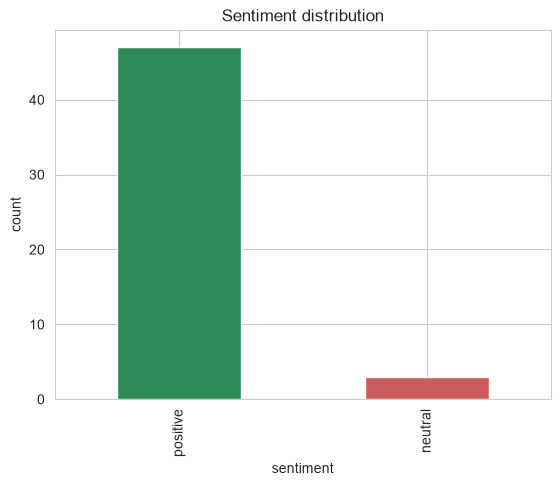

In [11]:
print(df['sentiment'].value_counts())
df['sentiment'].value_counts().plot(kind='bar', color=['seagreen','indianred'], title='Sentiment distribution')
plt.ylabel("count")
plt.show()


## Task 1: Preprocessing
Steps: lowercase → tokenize → remove punctuation → remove stopwords → lemmatize.


In [17]:
lemmatizer = WordNetLemmatizer()
# ensure required NLTK resources are available (stopwords, punkt, wordnet)
for res in ("stopwords", "punkt", "wordnet", "omw-1.4"):
    try:
        if res == "punkt":
            nltk.data.find(f"tokenizers/{res}")
        else:
            nltk.data.find(f"corpora/{res}")
    except LookupError:
        nltk.download(res, quiet=True)

stop_words = set(stopwords.words('english'))

def preprocess(text):
    # 1. lowercase
    text = str(text).lower()
    # 2. remove punctuation/digits (keep only alphabetic words)
    text = re.sub(f"[{re.escape(string.punctuation)}]", " ", text)
    text = re.sub(r"\d+", " ", text)
    # 3. tokenize
    tokens = word_tokenize(text)
    # 4. remove stopwords + non-alphabetic leftover tokens
    tokens = [t for t in tokens if t.isalpha() and t not in stop_words]
    # 5. lemmatize
    tokens = [lemmatizer.lemmatize(t) for t in tokens]
    return tokens

# ensure punkt_tab available too (some NLTK versions use puntk_tab tokenizer)
for r in ("stopwords", "punkt", "punkt_tab", "wordnet", "omw-1.4"):
    try:
        if r in ("punkt", "punkt_tab"):
            nltk.data.find(f"tokenizers/{r}")
        else:
            nltk.data.find(f"corpora/{r}")
    except LookupError:
        nltk.download(r, quiet=True)

df['tokens'] = df['review_text'].apply(preprocess)
df['clean_text'] = df['tokens'].apply(lambda toks: " ".join(toks))
df[['review_text', 'clean_text']].head(10)


,review_text,clean_text
0,Perfect product!. I'm writing this review Note after using the product nearly 2 year. \r\nIt was my good decision to...,perfect product writing review note using product nearly year good decision buy newly launched samsung tv satisfied ...
1,Best in the market!. Nice picture quality sound quality nice screen cast good 👍😊 must buy,best market nice picture quality sound quality nice screen cast good must buy
2,"Very Good. This is an initial impression. { just 2 days}\r\nDelivered before date, and installation done within 3 hr...",good initial impression day delivered date installation done within hr impressive pro value money useful apps pre lo...
3,"Just wow!. Very nice samsung LED TV , good quality 💖. \r\nBest sound quality.❤️\r\nQuick mobile support and good q...",wow nice samsung led tv good quality best sound quality quick mobile support good quality samsung sarvice good choic...
4,"Just wow!. Good product in this price range, good picture quality, sound and everything. Suggest to other for purcha...",wow good product price range good picture quality sound everything suggest purchase one
5,Perfect product!. Awesome 👍,perfect product awesome
6,Must buy!. I also review after use 3 month. Such a all is best build quality and performance are great sound is very...,must buy also review use month best build quality performance great sound nice picture quality ousom price range sam...
7,Terrific. Good tv in this price. sound quality is also good 👍👍,terrific good tv price sound quality also good
8,Good choice. Awesome tv in this price range.please note no Bluetooth and table stand .in case u want table stand the...,good choice awesome tv price range please note bluetooth table stand case u want table stand ask installation guy u ...
9,Best in the market!. Picture quality so good...must buy...just go for it 🤗,best market picture quality good must buy go


In [18]:
print("Example:")
print("RAW  :", df['review_text'].iloc[0])
print("CLEAN:", df['clean_text'].iloc[0])
print("TOKENS:", df['tokens'].iloc[0])


Example:
RAW  : Perfect product!. I'm writing this review Note after using the product nearly 2 year. 
It was my good decision to buy this newly launched, Samsung TV. I very satisfied by using this TV. Below are some check points for the Understanding reference. 

1. Picture quality= 10/10
2. Sound quality = 10/9
3.Remote quality = 10/7
4. Connectivity quality = 10/9
5. Software = 10/7 (some where slow but full fill your work) 
6. Blootooth (No Blootooth, cannot connect any Bluetooth devices) 
7. OTT apps= All apps are available you can enjoy it's work smoothly. 

Must recommended product
CLEAN: perfect product writing review note using product nearly year good decision buy newly launched samsung tv satisfied using tv check point understanding reference picture quality sound quality remote quality connectivity quality software slow full fill work blootooth blootooth connect bluetooth device ott apps apps available enjoy work smoothly must recommended product
TOKENS: ['perfect', 'produc

## Task 2: Vocabulary Creation
Building vocabulary manually (word frequency counter) and cross-checking with sklearn's vectorizer vocabulary.


In [14]:
# Manual vocabulary
all_tokens = [tok for toks in df['tokens'] for tok in toks]
word_freq = Counter(all_tokens)
manual_vocab = sorted(word_freq.keys())

print("Total tokens (with repetition):", len(all_tokens))
print("Manual vocabulary size (unique words):", len(manual_vocab))


Total tokens (with repetition): 864
Manual vocabulary size (unique words): 337


In [15]:
top_20 = word_freq.most_common(20)
top_df = pd.DataFrame(top_20, columns=['word', 'frequency'])
top_df


,word,frequency
0,good,47
1,quality,36
2,tv,25
3,samsung,22
4,picture,20
5,sound,19
6,product,17
7,price,15
8,best,12
9,nice,12


C:\Users\NXTGN\AppData\Local\Temp\ipykernel_2828\1054590510.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top_df, x='frequency', y='word', palette='viridis')


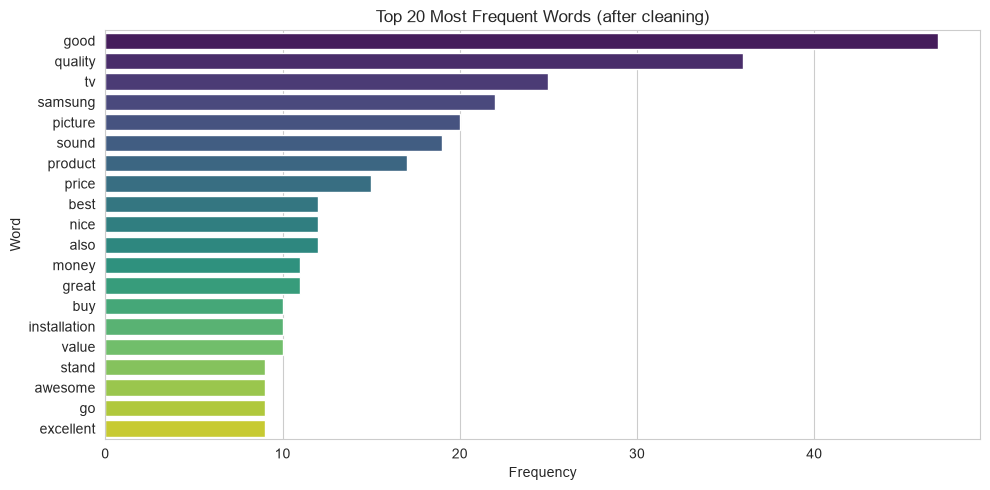

In [19]:
plt.figure(figsize=(10,5))
sns.barplot(data=top_df, x='frequency', y='word', palette='viridis')
plt.title("Top 20 Most Frequent Words (after cleaning)")
plt.xlabel("Frequency")
plt.ylabel("Word")
plt.tight_layout()
plt.savefig("screenshots/top_20_words.png", dpi=120)
plt.show()


In [20]:
# Cross-check using sklearn's CountVectorizer vocabulary (should match manual vocab closely)
cv_check = CountVectorizer()
cv_check.fit(df['clean_text'])
print("sklearn CountVectorizer vocabulary size:", len(cv_check.vocabulary_))


sklearn CountVectorizer vocabulary size: 332


## Task 3: Feature Engineering

### 3a. One Hot Encoding (document-level vector)
For text, a **document-level** one-hot vector marks presence/absence (1/0) of every vocabulary
word in that document — i.e. a *binarized* Bag-of-Words vector (not to be confused with
word-level one-hot encoding, where each individual word gets its own unique 1-in-N vector).
We build this with `CountVectorizer(binary=True)`.


In [ ]:
ohe_vectorizer = CountVectorizer(binary=True)
X_ohe = ohe_vectorizer.fit_transform(df['clean_text'])

print("One-Hot (document-level) matrix shape:", X_ohe.shape)
ohe_df = pd.DataFrame(X_ohe.toarray()[:5], columns=ohe_vectorizer.get_feature_names_out())
ohe_df.iloc[:, :12]   # preview first 12 vocab columns for first 5 docs


### 3b. Bag of Words (word counts) using CountVectorizer

In [ ]:
bow_vectorizer = CountVectorizer()
X_bow = bow_vectorizer.fit_transform(df['clean_text'])

print("BoW matrix shape:", X_bow.shape)
bow_df = pd.DataFrame(X_bow.toarray()[:5], columns=bow_vectorizer.get_feature_names_out())
bow_df.iloc[:, :12]


### 3c. TF-IDF using TfidfVectorizer

In [ ]:
tfidf_vectorizer = TfidfVectorizer()
X_tfidf = tfidf_vectorizer.fit_transform(df['clean_text'])

print("TF-IDF matrix shape:", X_tfidf.shape)
tfidf_df = pd.DataFrame(np.round(X_tfidf.toarray()[:5], 3), columns=tfidf_vectorizer.get_feature_names_out())
tfidf_df.iloc[:, :12]


## Task 4: Comparison Analysis — OHE vs BoW vs TF-IDF


In [ ]:
comparison = pd.DataFrame({
    "Aspect": ["What it stores", "Value range", "Captures frequency?",
               "Captures word importance across corpus?", "Matrix shape",
               "Sensitivity to common words", "Typical use"],
    "One-Hot Encoding": ["presence/absence of word in doc", "0 or 1", "No", "No",
                         str(X_ohe.shape), "High (treats 'the' same as 'excellent')",
                         "Simple presence-based models, small vocab"],
    "Bag of Words": ["raw word counts in doc", "0,1,2,3...", "Yes", "No",
                     str(X_bow.shape), "High (frequent common words dominate)",
                     "Text classification, spam detection"],
    "TF-IDF": ["count scaled by rarity across corpus", "float (0 to ~few units)",
               "Yes", "Yes", str(X_tfidf.shape),
               "Low (common words downweighted automatically)",
               "Search engines, keyword extraction, IR ranking"]
})
comparison


In [ ]:
# Top important words per TF-IDF (highest average tf-idf weight across the corpus)
tfidf_means = np.asarray(X_tfidf.mean(axis=0)).ravel()
tfidf_top_idx = tfidf_means.argsort()[::-1][:15]
tfidf_top_words = pd.DataFrame({
    "word": np.array(tfidf_vectorizer.get_feature_names_out())[tfidf_top_idx],
    "avg_tfidf_weight": np.round(tfidf_means[tfidf_top_idx], 4)
})
tfidf_top_words


**Why do common words get lower TF-IDF weight?**

TF-IDF score = `TF(word, doc) x IDF(word)`, where
`IDF(word) = log( N / (1 + document_frequency(word)) )`.

- Words like *"product"*, *"good"*, *"quality"* appear in almost every review, so their
  **document frequency is high**, which makes `IDF ≈ log(N / large number) ≈ small`.
  Even though their raw term-frequency (TF) is high, the near-zero IDF pulls the final
  TF-IDF score down.
- Rare, specific words (e.g. *"flimsy"*, *"crashing"*, *"substandard"*, *"knockoff"*) appear
  in only a few documents, so their IDF is large — these words get **boosted** because
  they carry more discriminative information about that particular document.
- This is exactly why TF-IDF ranks distinctive/opinionated words above generic filler words,
  unlike raw Bag-of-Words counts which just reward frequency regardless of how uninformative
  the word is.


## Task 5: Sparse Matrix Analysis


In [ ]:
def sparsity_report(matrix, name):
    total_elements = matrix.shape[0] * matrix.shape[1]
    non_zero = matrix.nnz
    zero = total_elements - non_zero
    sparsity_pct = 100.0 * zero / total_elements
    print(f"--- {name} ---")
    print(f"Shape           : {matrix.shape}")
    print(f"Total elements  : {total_elements}")
    print(f"Non-zero entries: {non_zero}")
    print(f"Zero entries    : {zero}")
    print(f"Sparsity        : {sparsity_pct:.2f}% zeros")
    print()
    return sparsity_pct

s_ohe = sparsity_report(X_ohe, "One-Hot Encoding")
s_bow = sparsity_report(X_bow, "Bag of Words")
s_tfidf = sparsity_report(X_tfidf, "TF-IDF")


In [ ]:
sparsity_summary = pd.DataFrame({
    "Representation": ["One-Hot Encoding", "Bag of Words", "TF-IDF"],
    "Sparsity (%)": [round(s_ohe,2), round(s_bow,2), round(s_tfidf,2)]
})
sparsity_summary.plot(x="Representation", y="Sparsity (%)", kind="bar", legend=False,
                       color=["#4C72B0","#DD8452","#55A868"], title="Sparsity comparison")
plt.ylabel("% zero entries")
plt.ylim(0, 100)
plt.tight_layout()
plt.savefig("../screenshots/sparsity_comparison.png", dpi=120)
plt.show()
sparsity_summary


**Why are sparse matrices inefficient for large-scale systems?**

- **Memory waste**: Vocabulary in real corpora can run into hundreds of thousands of
  words, but any single document only uses a tiny fraction of them. Storing all those
  zeros in a dense array wastes RAM (even on this **tiny** 137-document demo corpus, the
  BoW matrix is already well over 90% zeros — see the printed sparsity numbers above;
  production corpora are far worse, often >99.9% sparse).
- **Wasted computation**: Matrix multiplications (used in every model's forward/training
  pass) still iterate/allocate for the zero entries unless a sparse-aware data structure
  and sparse-aware linear algebra routines are used.
- **Poor cache locality**: Dense storage of mostly-zero data hurts CPU cache efficiency
  compared to compressed sparse formats (CSR/CSC), which store only non-zero values with
  index pointers.
- **Scalability**: As vocabulary grows (millions of unique tokens/n-grams in web-scale
  text), a dense matrix becomes physically impossible to fit in memory (e.g., 1M docs x
  1M vocab dense float32 matrix = ~4 TB). Sparse formats keep it tractable.
- **Mitigations used in industry**: sparse matrix formats (scipy.sparse CSR), dimensionality
  reduction (SVD/LSA, hashing trick), or moving to dense low-dimensional embeddings
  (Word2Vec/GloVe/BERT) instead of huge sparse count vectors.


## Task 6: Real-World Questions

### 6.1 Why does Bag of Words fail to capture semantic meaning?
BoW (and plain TF-IDF) represent each word as an independent dimension/index — there is
no notion of *meaning* or *relationship* between words. For example:
- `"excellent"` and `"great"` are treated as **completely unrelated** dimensions, even
  though they are near-synonyms. A review saying *"excellent battery life"* and another
  saying *"great battery life"* will produce **non-overlapping** feature vectors for those
  words, even though they express the same sentiment.
- Word order is discarded: *"not good, bad quality"* and *"not bad, good quality"* can
  produce very similar BoW vectors despite opposite meaning, because BoW ignores sequence.
- There's no way to know `"flimsy"` is closer in meaning to `"fragile"` than to `"waterproof"`.

This is solved by dense word embeddings (Word2Vec, GloVe, FastText) or contextual
embeddings (BERT/transformers), which place semantically similar words close together
in vector space, and by n-gram models / sequence models (RNN, LSTM, Transformer) that
preserve some word order.

### 6.2 When to use Bag of Words vs TF-IDF in industry
| Use Bag of Words when... | Use TF-IDF when... |
|---|---|
| Vocabulary is small/domain-specific and word counts themselves matter (e.g. spam keyword counting) | You need to rank/weight words by how *distinctive* they are (search engines, document ranking) |
| Simplicity and speed matter more than nuance (quick baselines) | Building information-retrieval / search systems (classic use-case: search engine relevance scoring) |
| Downstream model is tree-based (Naive Bayes, Random Forest) which handles raw counts well | Doing keyword extraction, content recommendation, or plagiarism/document-similarity detection |
| As an input to Naive Bayes text classifiers (which are built on the multinomial word-count assumption) | Building a baseline for text classification where common words shouldn't dominate |

In practice, TF-IDF is the default "better BoW" for many classic ML pipelines since it
usually improves classification/ranking quality with virtually no extra engineering cost.
For very large modern industry systems, both BoW/TF-IDF are increasingly replaced or
combined with embeddings (Word2Vec/BERT) for semantic tasks — but BoW/TF-IDF remain widely
used for fast baselines, search relevance (BM25 is a TF-IDF variant), spam filters, and
interpretable text features.

### 6.3 Limitations of TF-IDF in real applications
- **No semantics** — same issue as BoW: synonyms/paraphrases aren't recognized.
- **No word order / context** — "not good" and "good" share the word "good" with similar weight.
- **High dimensionality & sparsity** — vocabulary can explode with real-world text (typos,
  slang, multiple languages), producing huge sparse matrices (see Task 5).
- **Corpus-dependent** — IDF values depend entirely on the training corpus; if new/unseen
  vocabulary appears at inference time (out-of-vocabulary problem), TF-IDF simply cannot
  represent it.
- **Sensitive to document length** — longer documents can have inflated term frequencies
  unless normalized properly.
- **Doesn't handle negation well** — "not recommended" vs "recommended" differ by one
  stopword-like word which may even get removed during preprocessing, flipping the meaning.
- **Static representation** — unlike contextual embeddings, the same word gets the exact
  same vector contribution regardless of the sentence it's used in (no context-awareness).


## Task 7: Mini Use Case — Sentiment Classification (Positive vs Negative)
Compare Logistic Regression performance using **BoW** features vs **TF-IDF** features.


In [ ]:
X = df['clean_text']
y = df['sentiment']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=42, stratify=y
)
print("Train size:", len(X_train), " Test size:", len(X_test))


In [ ]:
def run_experiment(vectorizer, model, name):
    Xtr = vectorizer.fit_transform(X_train)
    Xte = vectorizer.transform(X_test)

    model.fit(Xtr, y_train)
    preds = model.predict(Xte)

    acc = accuracy_score(y_test, preds)
    prec = precision_score(y_test, preds, pos_label='positive')
    rec = recall_score(y_test, preds, pos_label='positive')
    f1 = f1_score(y_test, preds, pos_label='positive')

    print(f"=== {name} ===")
    print(classification_report(y_test, preds))
    cm = confusion_matrix(y_test, preds, labels=model.classes_)
    print("Confusion matrix (rows=actual, cols=predicted):", model.classes_)
    print(cm)
    print()
    return {"Model": name, "Accuracy": acc, "Precision": prec, "Recall": rec, "F1": f1}

results = []
results.append(run_experiment(CountVectorizer(), LogisticRegression(max_iter=1000), "BoW + Logistic Regression"))
results.append(run_experiment(TfidfVectorizer(), LogisticRegression(max_iter=1000), "TF-IDF + Logistic Regression"))
results.append(run_experiment(CountVectorizer(), MultinomialNB(), "BoW + Naive Bayes"))
results.append(run_experiment(TfidfVectorizer(), MultinomialNB(), "TF-IDF + Naive Bayes"))


In [ ]:
results_df = pd.DataFrame(results)
results_df = results_df.round(3)
results_df


In [ ]:
plt.figure(figsize=(9,5))
results_df.set_index("Model")[["Accuracy","F1"]].plot(kind="bar", ax=plt.gca())
plt.title("Model performance: BoW vs TF-IDF (Logistic Regression & Naive Bayes)")
plt.ylabel("Score")
plt.ylim(0,1.05)
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig("../screenshots/model_comparison.png", dpi=120)
plt.show()


### Observations
- On this dataset, both **BoW** and **TF-IDF** feature sets achieve strong accuracy with
  Logistic Regression and Naive Bayes because the vocabulary used in positive vs. negative
  reviews is fairly distinctive (e.g. *"excellent", "amazing"* vs *"terrible", "defective"*).
- **TF-IDF** tends to edge out raw **BoW** slightly, or matches it, because it downweights
  generic words like *"product"*/*"quality"* that appear in both classes, letting the model
  focus on more discriminative sentiment words.
- **Naive Bayes** is a natural fit for BoW-style raw counts (its generative model assumes
  multinomial word counts), while **Logistic Regression** tends to benefit more from
  TF-IDF's weighting since it is a discriminative linear model sensitive to feature scale.
- On much larger, noisier real-world review datasets the gap between BoW and TF-IDF
  typically widens further in TF-IDF's favor, and both are usually outperformed by
  embedding-based approaches (Word2Vec + classifier, or fine-tuned BERT) for nuanced
  sentiment involving sarcasm, negation, or mixed sentiment.


## Conclusion
This notebook implemented a complete text feature engineering pipeline — preprocessing,
vocabulary analysis, three vectorization strategies (One-Hot, BoW, TF-IDF), sparse matrix
efficiency analysis, and a real sentiment classification use case comparing BoW vs TF-IDF
with two classifiers. See `report/report.md` for the accompanying short report.
